In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
video_folder = "/storage/group/cmg25/default/osmia_data"
output_folder = "/storage/group/cmg25/default/osmia_data_processing_output"

In [3]:
files = os.listdir(video_folder)

In [4]:
df = pd.DataFrame(files, columns=["filename"])

In [5]:
#['mendels', '2024-04-16', '15', '21', '24']
# [site, date, hour, minute, second]

df["site"] = df["filename"].apply(lambda x: x.split(".")[0].split("_")[0])
df["date"] = df["filename"].apply(lambda x: x.split(".")[0].split("_")[1])
df["hour"] = df["filename"].apply(lambda x: x.split(".")[0].split("_")[2])
df["minute"] = df["filename"].apply(lambda x: x.split(".")[0].split("_")[3])

In [6]:
# filter site
df_m = df[df['site'] == 'mendels']
df_n = df[df['site'] == 'natalies']

In [7]:
hours_list = [8,9,10,11,12,13,14,15,16,17,18,19]

In [8]:
def is_valid_hour(hour):
    try:
        hour_int = int(hour)
        return hour_int in hours_list
    except ValueError:
        return False

df_m_valid = df_m[df_m['hour'].apply(is_valid_hour)]
df_n_valid = df_n[df_n['hour'].apply(is_valid_hour)]

/tmp/ipykernel_645537/2798533468.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m_2024['date'] = pd.to_datetime(df_m_2024['date'])
/tmp/ipykernel_645537/2798533468.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m_2024['time'] = pd.to_datetime(


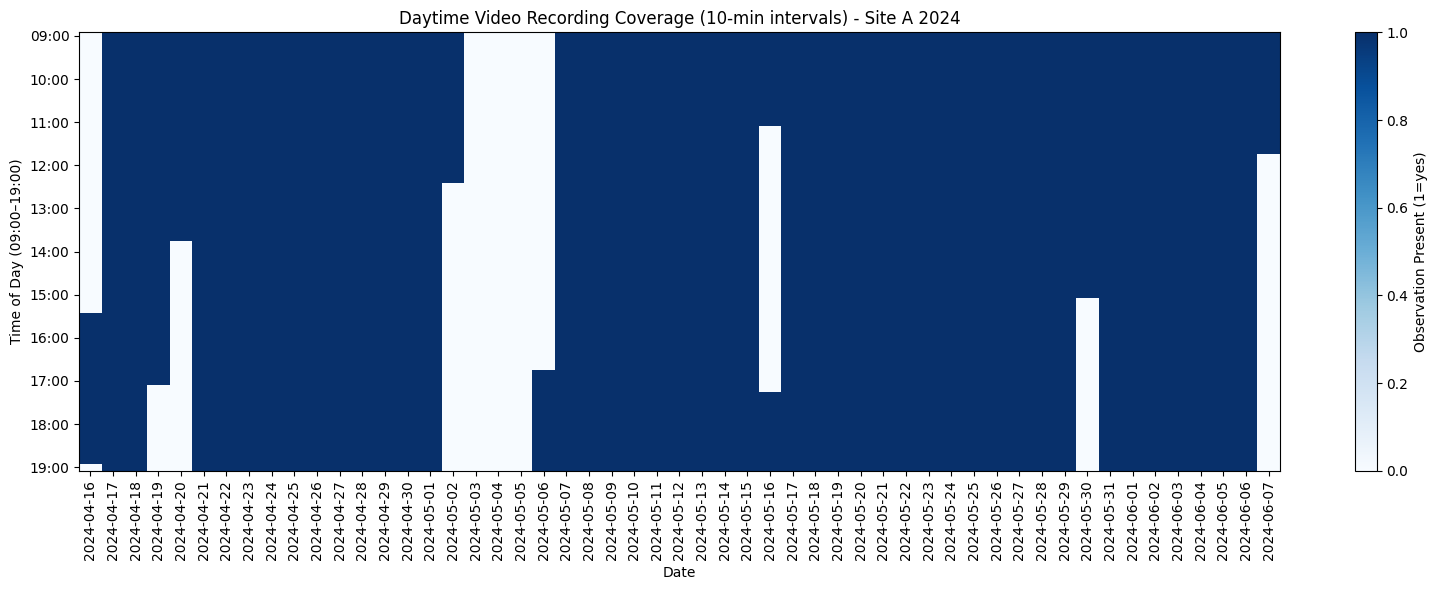

In [9]:
df_m_2024 = df_m_valid[~df_m_valid['date'].str.contains('2025')]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure date is datetime
df_m_2024['date'] = pd.to_datetime(df_m_2024['date'])

# Create time column
df_m_2024['time'] = pd.to_datetime(
    df_m_2024['hour'].astype(str).str.zfill(2) + ":" +
    df_m_2024['minute'].astype(str).str.zfill(2),
    format="%H:%M"
).dt.time

# Define 10-min slots from 09:00 to 19:00
time_slots = pd.date_range("09:00", "19:00", freq="10min").time

# Build pivot table
coverage = (
    df_m_2024
    .assign(value=1)
    .pivot_table(index='date', columns='time', values='value', fill_value=0)
)

# Restrict to new time window
coverage = coverage.reindex(columns=time_slots, fill_value=0)

# Plot
plt.figure(figsize=(16, 6))
plt.imshow(coverage.T, aspect='auto', cmap='Blues')

# X-axis
plt.xticks(range(len(coverage.index)),
           coverage.index.strftime('%Y-%m-%d'),
           rotation=90)

# Show only hourly ticks on Y-axis
hourly_positions = [i for i, t in enumerate(time_slots) if t.minute == 0]
hourly_labels = [t.strftime("%H:%M") for t in time_slots if t.minute == 0]

plt.yticks(hourly_positions, hourly_labels)

plt.xlabel("Date")
plt.ylabel("Time of Day (09:00–19:00)")
plt.title("Daytime Video Recording Coverage (10-min intervals) - Site A 2024")
plt.colorbar(label="Observation Present (1=yes)")

plt.tight_layout()
plt.show()



/tmp/ipykernel_645537/2440200964.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m_2025['date'] = pd.to_datetime(df_m_2025['date'])
/tmp/ipykernel_645537/2440200964.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m_2025['time'] = pd.to_datetime(


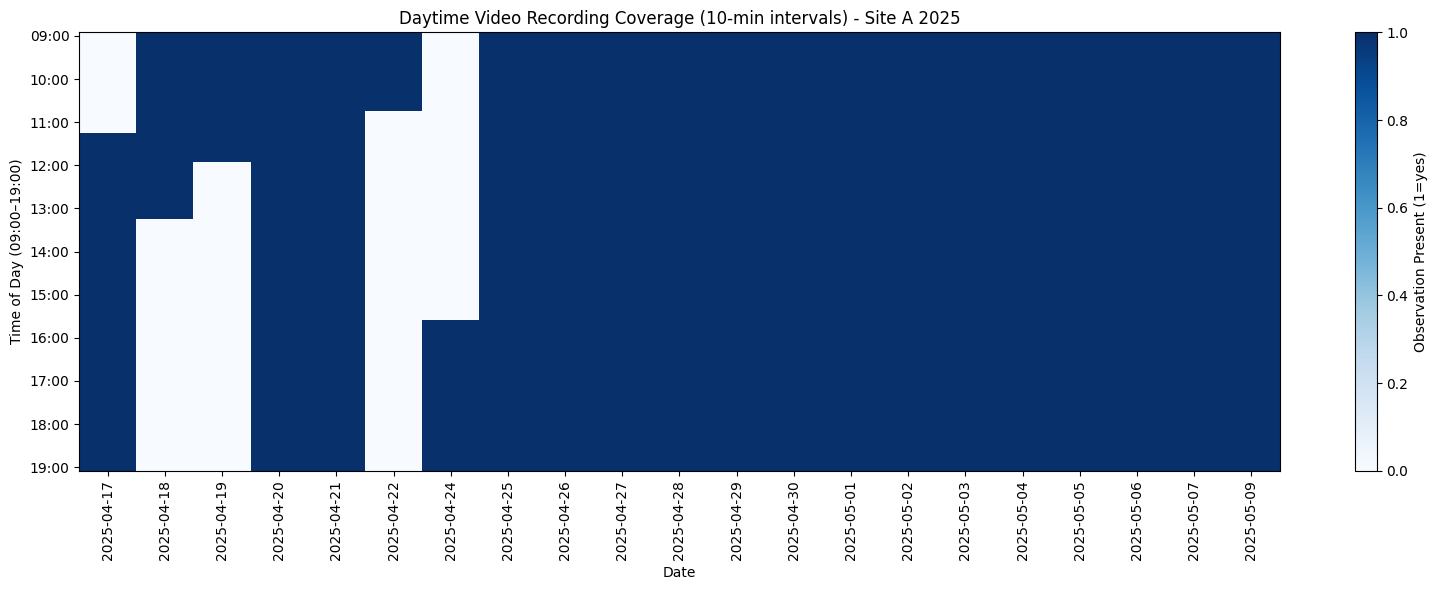

In [10]:
df_m_2025 = df_m_valid[~df_m_valid['date'].str.contains('2024')]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure date is datetime
df_m_2025['date'] = pd.to_datetime(df_m_2025['date'])

# Create time column
df_m_2025['time'] = pd.to_datetime(
    df_m_2025['hour'].astype(str).str.zfill(2) + ":" +
    df_m_2025['minute'].astype(str).str.zfill(2),
    format="%H:%M"
).dt.time

# Define 10-min slots from 09:00 to 19:00
time_slots = pd.date_range("09:00", "19:00", freq="10min").time

# Build pivot table
coverage = (
    df_m_2025   
    .assign(value=1)
    .pivot_table(index='date', columns='time', values='value', fill_value=0)
)

# Restrict to new time window
coverage = coverage.reindex(columns=time_slots, fill_value=0)

# Plot
plt.figure(figsize=(16, 6))
plt.imshow(coverage.T, aspect='auto', cmap='Blues')

# X-axis
plt.xticks(range(len(coverage.index)),
           coverage.index.strftime('%Y-%m-%d'),
           rotation=90)

# Show only hourly ticks on Y-axis
hourly_positions = [i for i, t in enumerate(time_slots) if t.minute == 0]
hourly_labels = [t.strftime("%H:%M") for t in time_slots if t.minute == 0]

plt.yticks(hourly_positions, hourly_labels)

plt.xlabel("Date")
plt.ylabel("Time of Day (09:00–19:00)")
plt.title("Daytime Video Recording Coverage (10-min intervals) - Site A 2025")
plt.colorbar(label="Observation Present (1=yes)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_645537/560406290.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_n_valid['date'] = pd.to_datetime(df_n_valid['date'])
/tmp/ipykernel_645537/560406290.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_n_valid['time'] = pd.to_datetime(


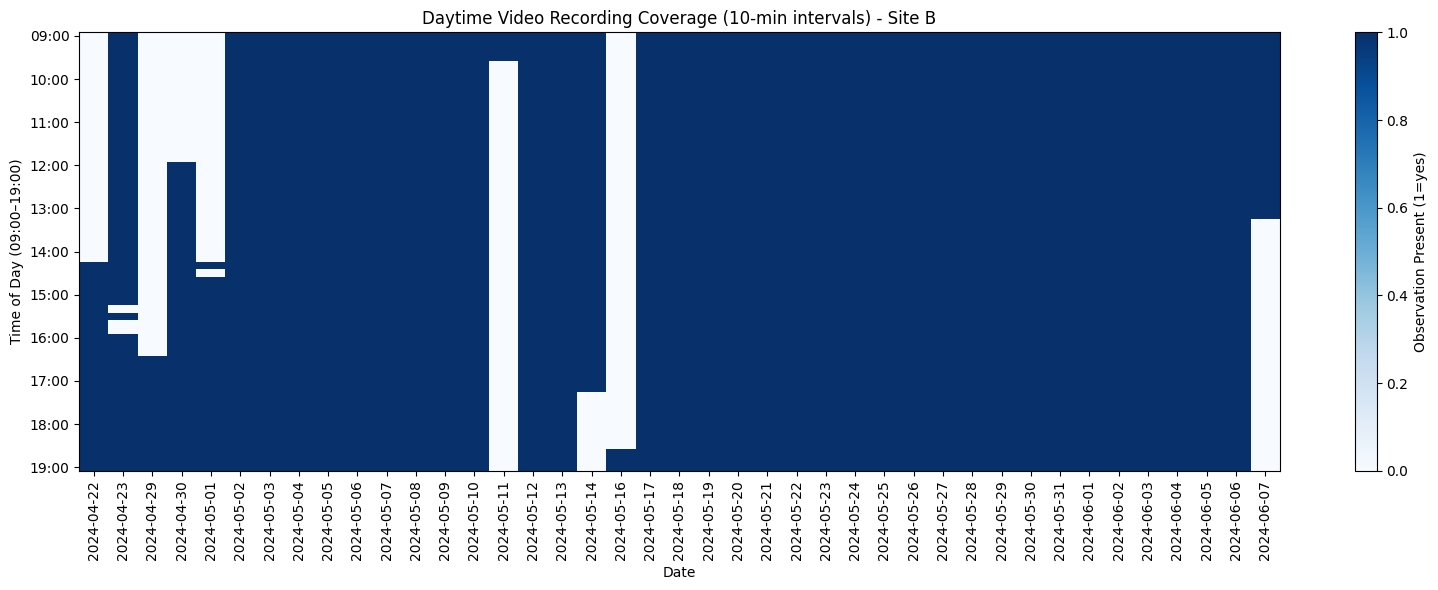

In [11]:
df_n_valid

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure date is datetime
df_n_valid['date'] = pd.to_datetime(df_n_valid['date'])

# Create time column
df_n_valid['time'] = pd.to_datetime(
    df_n_valid['hour'].astype(str).str.zfill(2) + ":" +
    df_n_valid['minute'].astype(str).str.zfill(2),
    format="%H:%M"
).dt.time

# Define 10-min slots from 09:00 to 19:00
time_slots = pd.date_range("09:00", "19:00", freq="10min").time

# Build pivot table
coverage = (
    df_n_valid   
    .assign(value=1)
    .pivot_table(index='date', columns='time', values='value', fill_value=0)
)

# Restrict to new time window
coverage = coverage.reindex(columns=time_slots, fill_value=0)

# Plot
plt.figure(figsize=(16, 6))
plt.imshow(coverage.T, aspect='auto', cmap='Blues')

# X-axis
plt.xticks(range(len(coverage.index)),
           coverage.index.strftime('%Y-%m-%d'),
           rotation=90)

# Show only hourly ticks on Y-axis
hourly_positions = [i for i, t in enumerate(time_slots) if t.minute == 0]
hourly_labels = [t.strftime("%H:%M") for t in time_slots if t.minute == 0]

plt.yticks(hourly_positions, hourly_labels)

plt.xlabel("Date")
plt.ylabel("Time of Day (09:00–19:00)")
plt.title("Daytime Video Recording Coverage (10-min intervals) - Site B")
plt.colorbar(label="Observation Present (1=yes)")

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

def percent_full_coverage(df, start="09:00", end="19:00", freq="10min"):
    df = df.copy()

    df['date'] = pd.to_datetime(df['date'])

    df['time'] = pd.to_datetime(
        df['hour'].astype(str).str.zfill(2) + ":" +
        df['minute'].astype(str).str.zfill(2),
        format="%H:%M"
    ).dt.time

    expected_slots = pd.date_range(start, end, freq=freq).time
    n_expected = len(expected_slots)

    daily_counts = (
        df[df['time'].isin(expected_slots)]
        .groupby('date')['time']
        .nunique()
    )

    full_days = (daily_counts == n_expected).sum()
    total_days = daily_counts.shape[0]
    pct = 100 * full_days / total_days if total_days else 0.0

    return full_days, total_days, pct

# Examples:
print(percent_full_coverage(df_m_2024))
print(percent_full_coverage(df_m_2025))
print(percent_full_coverage(df_n_valid))


(np.int64(42), 50, np.float64(84.0))
(np.int64(16), 21, np.float64(76.19047619047619))
(np.int64(32), 41, np.float64(78.04878048780488))


In [25]:
len(df_m_2024['date'].unique().tolist())

53

In [26]:
len(df_m_2025['date'].unique().tolist())

21

In [27]:
len(df_n_valid['date'].unique().tolist())

41

In [37]:
import pandas as pd
from itertools import groupby
from operator import itemgetter

def percent_full_coverage_all_days(df, start="09:00", end="19:00", freq="10min", verbose=True):
    df = df.copy()

    df['date'] = pd.to_datetime(df['date'])

    df['time'] = pd.to_datetime(
        df['hour'].astype(str).str.zfill(2) + ":" +
        df['minute'].astype(str).str.zfill(2),
        format="%H:%M"
    ).dt.time

    expected_slots = pd.date_range(start, end, freq=freq).time
    n_expected = len(expected_slots)

    all_days = pd.Index(sorted(df['date'].unique()))

    df_daytime = df[df['time'].isin(expected_slots)]

    daily_counts = (
        df_daytime
        .groupby('date')['time']
        .nunique()
        .reindex(all_days, fill_value=0)
    )

    full_days = int((daily_counts == n_expected).sum())
    total_days = int(len(all_days))
    pct = 100 * full_days / total_days if total_days else 0.0

    zero_days = sorted(daily_counts[daily_counts == 0].index)

    # Group consecutive dates
    consecutive_blocks = []
    if zero_days:
        ordinal_dates = [d.toordinal() for d in zero_days]

        for _, group in groupby(enumerate(ordinal_dates),
                                lambda x: x[0] - x[1]):
            block = list(map(itemgetter(1), group))
            start_date = pd.Timestamp.fromordinal(block[0])
            end_date = pd.Timestamp.fromordinal(block[-1])
            consecutive_blocks.append((start_date, end_date))

    if verbose:
        print(f"\nEvaluation window: {start}–{end}")
        print(f"Expected slots per day: {n_expected}")
        print(f"Full coverage days: {full_days}")
        print(f"Total deployment days: {total_days}")
        print(f"Percentage full coverage: {pct:.2f}%")

        if zero_days:
            print("\nDays with ZERO daytime recordings (counted as failed):")
            for d in zero_days:
                print(d.date())

            print("\nConsecutive zero-day blocks:")
            for start_date, end_date in consecutive_blocks:
                if start_date == end_date:
                    print(f"{start_date.date()}")
                else:
                    print(f"{start_date.date()} → {end_date.date()}")
        else:
            print("\nNo zero-daytime-recording days.")

    return full_days, total_days, pct, consecutive_blocks


percent_full_coverage_all_days(df_m_2024)
percent_full_coverage_all_days(df_m_2025)
percent_full_coverage_all_days(df_n_valid)



Evaluation window: 09:00–19:00
Expected slots per day: 61
Full coverage days: 42
Total deployment days: 53
Percentage full coverage: 79.25%

Days with ZERO daytime recordings (counted as failed):
2024-05-03
2024-05-04
2024-05-05

Consecutive zero-day blocks:
2024-05-03 → 2024-05-05

Evaluation window: 09:00–19:00
Expected slots per day: 61
Full coverage days: 16
Total deployment days: 21
Percentage full coverage: 76.19%

No zero-daytime-recording days.

Evaluation window: 09:00–19:00
Expected slots per day: 61
Full coverage days: 32
Total deployment days: 41
Percentage full coverage: 78.05%

No zero-daytime-recording days.


(32, 41, 78.04878048780488, [])

In [1]:
import os

In [38]:
output_folder

'/storage/group/cmg25/default/osmia_data_processing_output'

In [39]:
fls = os.listdir(output_folder)

In [44]:
len([f for f in fls if f.endswith("results.csv")])

1515

In [43]:
len([f for f in fls if f.endswith("events.csv")])

1515

In [47]:
len([f for f in fls if f.endswith(".mp4")])

1515

In [48]:
fl = "mendels_2024-05-23_13_00_00.mp4"

In [52]:
vd = os.listdir(video_folder)

In [65]:
len([f for f in vd[1930:] if f.startswith("mendels_2024")])

900

In [66]:
[f for f in vd[1930:] if f.startswith("mendels_2024")]

['mendels_2024-05-23_12_50_01.mp4',
 'mendels_2024-05-23_13_00_00.mp4',
 'mendels_2024-05-23_13_10_00.mp4',
 'mendels_2024-05-23_13_20_01.mp4',
 'mendels_2024-05-23_13_30_00.mp4',
 'mendels_2024-05-23_13_40_00.mp4',
 'mendels_2024-05-23_13_50_01.mp4',
 'mendels_2024-05-23_14_00_00.mp4',
 'mendels_2024-05-23_14_10_00.mp4',
 'mendels_2024-05-23_14_20_01.mp4',
 'mendels_2024-05-23_14_30_00.mp4',
 'mendels_2024-05-23_14_40_00.mp4',
 'mendels_2024-05-23_14_50_01.mp4',
 'mendels_2024-05-23_15_00_00.mp4',
 'mendels_2024-05-23_15_10_00.mp4',
 'mendels_2024-05-23_15_20_00.mp4',
 'mendels_2024-05-23_15_30_00.mp4',
 'mendels_2024-05-23_15_40_01.mp4',
 'mendels_2024-05-23_15_50_00.mp4',
 'mendels_2024-05-23_16_00_00.mp4',
 'mendels_2024-05-23_16_10_01.mp4',
 'mendels_2024-05-23_16_20_00.mp4',
 'mendels_2024-05-23_16_30_00.mp4',
 'mendels_2024-05-23_16_40_01.mp4',
 'mendels_2024-05-23_16_50_00.mp4',
 'mendels_2024-05-23_17_00_00.mp4',
 'mendels_2024-05-23_17_10_01.mp4',
 'mendels_2024-05-23_17_20_0